In [1]:
import requests
import json
from geojson import Point, Feature, FeatureCollection, dump

import geopandas as gpd

from tqdm import tqdm
import glob


## OBS Daten von den jeweiligen Portalen (als geojson) exportieren

### Verfügbare Portale

* https://obs.adfc-brandenburg.de/
* https://obs.adfc-bw.de/
* https://obs.radentscheid-essen.de/
* https://portal.openbikesensor.org/
* https://obs.adfc-darmstadt.de/
* https://obs.adfc-osnabrueck.de/


* https://obs.adfc-ac.de/
* https://obs-portal.pub.solar/ (Köln)
* https://obs.adfc-luebeck.de/
* https://portal.1meter50.at/ (Österreich)
* https://portal.openbikesensor.hamburg 

neu
* https://obs.adfc-hessen.de/
* https://nantes.1metre.fr/


In [2]:
portale_list= \
['https://obs.adfc-brandenburg.de/',
 'https://obs.adfc-bw.de/',
 'https://obs.radentscheid-essen.de/',
 'https://portal.openbikesensor.org/',
 'https://obs.adfc-darmstadt.de/',
 'https://obs.adfc-osnabrueck.de/',

 'https://obs.adfc-ac.de/',
 'https://obs-portal.pub.solar/',
 'https://obs.adfc-luebeck.de/',
 'https://portal.1meter50.at/',
 'https://portal.openbikesensor.hamburg/', 
 
 'https://obs.adfc-hessen.de/',
# 'https://nantes.1metre.fr/' ist down 13.11.24
]

In [3]:
#portale_list

In [4]:
#portale_list_str=[]
for p in portale_list:
    p_str=p.replace('https://','').replace('.de/','').replace('.org/','').replace('obs.','').replace('.pub.solar/','-koeln').replace('.','-').replace('/','')#.replace('-','_')
    print (p_str)
    #portale_list_str.append(p_str)

adfc-brandenburg
adfc-bw
radentscheid-essen
portal-openbikesensor
adfc-darmstadt
adfc-osnabrueck
adfc-ac
obs-portal-koeln
adfc-luebeck
portal-1meter50-at
portal-openbikesensor-hamburg
adfc-hessen


In [5]:
#portale_list_str_ = ', '.join([str(elem) for elem in portale_list_str])
#portale_list_str_

In [6]:
from datetime import date
today = date.today()
print("Today's date:", today)

Today's date: 2025-06-11


In [8]:
import os


In [9]:
datum=str(today)#"230503"

for p in tqdm(portale_list):
    url = p + "api/export/events?bbox=-0.19922377649033446,58.13748613913617,20.921758549385075,43.25705589043925&fmt=geojson"  #einfach riesiege bbbox fuer DACH
    
    # other bbox for france
    if p=="https://nantes.1metre.fr/":
        url = p + "api/export/events?bbox=-4.0938310596490215,48.7897019402069,0.08630978488054714,45.28213743625158&fmt=geojson"

    response = requests.request("GET", url)
    response_dict = json.loads(response.text)
    
    #p_str=p.replace('https://','').replace('.de/','').replace('.org/','').replace('obs.','').replace('.pub.solar/','-koeln')
    p_str=p.replace('https://','').replace('.de/','').replace('.org/','').replace('obs.','').replace('.pub.solar/','-koeln').replace('.','-').replace('/','')#.replace('-','_')


    os.makedirs("obs_data", exist_ok=True)

    with open('obs_data/'+datum+'_portalSnap_'+p_str+'.geojson', 'w') as f:
        dump(response_dict, f)

100%|██████████| 12/12 [01:56<00:00,  9.74s/it]


In [ ]:
#obs portal und obs brandnburg liefern aktuell keine Daten

## Files einlesen

In [11]:
files = glob.glob('obs_data/*.geojson')
len(files)

12

In [12]:
import pandas as pd

In [13]:
gdf =gpd.GeoDataFrame()

for f in tqdm(files):
    gdf_this = gpd.read_file(f, crs='EPSG:4326')
    portal_name=f.split('_')[-1].replace('.geojson','')
    datum_stand=f.split('_')[0].replace('portale\\','')
    
    gdf_this['portal']= portal_name

    #gdf=gdf.append(gdf_this)
    gdf=pd.concat([gdf,gdf_this])
    
    print ("portal_name: " + portal_name)
    print ("Anzahl Datenpunkte: " + str(len(gdf_this)))
    print ("Stand vom: " + datum_stand)
    
                                        
print ("\nAnzahl Datenpunkte gesamt: "+ str(len(gdf)))

  0%|          | 0/12 [00:00<?, ?it/s]/home/simon/unfallkarte/preprocessing/unfallkarte_env/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(
  8%|▊         | 1/12 [00:00<00:04,  2.44it/s]/home/simon/unfallkarte/preprocessing/unfallkarte_env/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(
 17%|█▋        | 2/12 [00:00<00:02,  3.77it/s]

portal_name: adfc-brandenburg
Anzahl Datenpunkte: 27569
Stand vom: obs
portal_name: adfc-luebeck
Anzahl Datenpunkte: 10504
Stand vom: obs


/home/simon/unfallkarte/preprocessing/unfallkarte_env/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(
 25%|██▌       | 3/12 [00:01<00:03,  2.84it/s]/home/simon/unfallkarte/preprocessing/unfallkarte_env/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(
 33%|███▎      | 4/12 [00:01<00:02,  3.73it/s]

portal_name: portal-openbikesensor-hamburg
Anzahl Datenpunkte: 43410
Stand vom: obs
portal_name: portal-1meter50-at
Anzahl Datenpunkte: 12705
Stand vom: obs


/home/simon/unfallkarte/preprocessing/unfallkarte_env/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(
 42%|████▏     | 5/12 [00:02<00:03,  2.01it/s]

...

portal_name: radentscheid-essen
Anzahl Datenpunkte: 22512
Stand vom: obs


 92%|█████████▏| 11/12 [00:04<00:00,  2.68it/s]/home/simon/unfallkarte/preprocessing/unfallkarte_env/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(


portal_name: obs-portal-koeln
Anzahl Datenpunkte: 16825
Stand vom: obs


100%|██████████| 12/12 [00:05<00:00,  2.30it/s]

portal_name: adfc-osnabrueck
Anzahl Datenpunkte: 53886
Stand vom: obs

Anzahl Datenpunkte gesamt: 465572


In [ ]:
# Duplikate löschen, falls User Daten auf mehrere Portale geladen haben
gdf=gdf.drop_duplicates(subset=['distance_overtaker','time','geometry']).copy()
gdf

,distance_overtaker,distance_stationary,direction,way_id,course,speed,time,zone,geometry,portal
0,0.85,NaN,1,27253388.0,1.677828,2.861111,2022-08-31 11:17:06+00:00,urban,POINT (13.0504 52.41743),adfc-brandenburg
1,1.47,0.63,-1,792463492.0,2.650435,4.138889,2022-09-01 06:03:24+00:00,urban,POINT (13.06348 52.40243),adfc-brandenburg
2,1.23,NaN,1,76214579.0,0.361340,3.027778,2022-09-06 20:22:37+00:00,urban,POINT (13.06024 52.39748),adfc-brandenburg
3,2.07,1.88,1,76214579.0,0.383441,2.916667,2022-09-06 20:22:42+00:00,urban,POINT (13.06051 52.39755),adfc-brandenburg
4,0.72,2.21,-1,10654946.0,5.008903,3.944444,2022-09-09 12:49:28+00:00,urban,POINT (13.06442 52.40733),adfc-brandenburg
...,...,...,...,...,...,...,...,...,...,...
53881,1.75,NaN,1,37334906.0,5.552477,6.250000,2025-06-11 14:36:22+00:00,NaN,POINT (7.89898 52.26164),adfc-osnabrueck
53882,1.26,NaN,1,37334906.0,6.090207,8.194444,2025-06-11 14:38:55+00:00,NaN,POINT (7.91297 52.25678),adfc-osnabrueck
53883,1.59,NaN,1,37334906.0,6.092936,8.194444,2025-06-11 14:38:59+00:00,NaN,POINT (7.91345 52.25672),adfc-osnabrueck
53884,2.31,1.18,1,30190656.0,4.964063,7.250000,2025-06-11 14:40:20+00:00,NaN,POINT (7.91887 52.25737),adfc-osnabrueck


In [16]:
import matplotlib.pyplot as plt
#import contextily as ctx
import matplotlib


get some shapes

In [23]:
# bland = gpd.read_file("https://raw.githubusercontent.com/isellsoap/deutschlandGeoJSON/main/2_bundeslaender/1_sehr_hoch.geo.json")
# bland.boundary.plot(color='gray')

<Axes: >

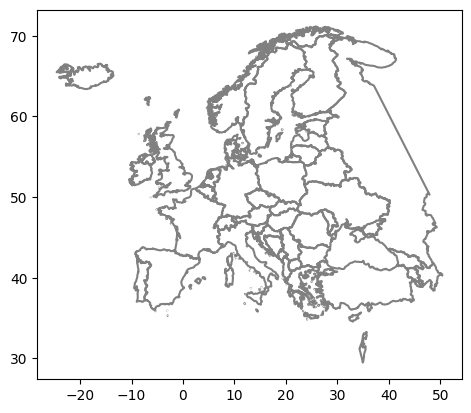

In [20]:
europe = gpd.read_file("https://raw.githubusercontent.com/leakyMirror/map-of-europe/master/GeoJSON/europe.geojson")
europe.boundary.plot(color='gray')

<Axes: >

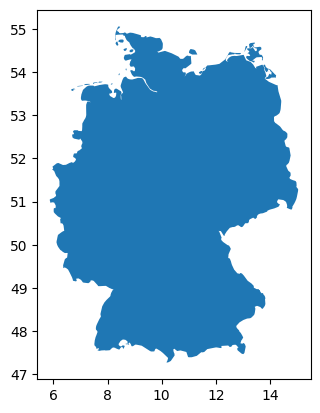

In [22]:
europe_fil=europe[europe.NAME.isin(['Germany'])]#.boundary#.plot()   #,'France'
europe_fil.plot()

In [ ]:
gdf = gdf[gdf.within(europe_fil.unary_union)]
gdf

In [31]:
gdf_clipped_ger=gdf.clip(europe_fil)

In [32]:
gdf_clipped_ger.to_file("obs_data/OBS_data_"+datum+".fgb", driver="FlatGeobuf")

In [33]:
def fgb_to_pmtiles(points_fgb, output_pmtiles, layer_name):
    import subprocess
    from pathlib import Path


    subprocess.run([
        "tippecanoe", "-o", output_pmtiles,
        f"--layer={layer_name}-points",
        "--minimum-zoom=6", "--maximum-zoom=14",
        "--force",
        "--no-feature-limit", "--no-tile-size-limit", "--force-feature-limit",
        "--drop-densest-as-needed",
        "--drop-rate=0",
        str(Path(points_fgb).resolve())
    ], check=True)


    print("✅ Combined PMTiles created")

In [34]:
fgb_to_pmtiles(
    points_fgb="obs_data/OBS_data_"+datum+".fgb",
    output_pmtiles="obs_data/OBS_data_"+datum+".pmtiles",
    layer_name="obs_data"
    )

detected indexed FlatGeobuf: assigning feature IDs by sequence
428737 features, 28278657 bytes of geometry and attributes, 18571029 bytes of string pool, 0 bytes of vertices, 0 bytes of nodes
  99.9%  14/8590/5518  


✅ Combined PMTiles created
